# Contouring control around a race track: one periodic spline for the whole track

Model predictive contouring control (MPCC) drives a car along a track as fast as the track
allows. It adds the car's progress along the centre line, $\theta$, as a state, and trades
progress against the distance from the line. The track enters the controller as a curve of
$\theta$ that the optimizer differentiates twice per iteration.

This notebook builds the whole track as one periodic, vector-valued cubic spline in arc length:
the centre line, the heading and the curvature, read off in one evaluation. The controller built
on it then drives a closed-loop lap of the Formula Student Driverless "competition 1" track. The
centre line is the one the race-car benchmark uses, 87 points, copied to `data/`.

| Scaly feature | Where |
| --- | --- |
| `interp.interpolant(bc="periodic")`, vector-valued | the track |
| `derivative()`, `to_scipy()` | arc length, heading, curvature |
| the spline in a stage cost and a path constraint, `extrap="periodic"` past a lap | the controller |
| `mpc.OCP`, `mpc.MPC`, the control law | a closed-loop lap |
| `write_module(ctrl.law)` | the generated C |

The CasADi pair `pairs/contouring_mpc` solves the same kind of controller with CasADi's `Opti`
and compares the two.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly import integrators as si
from scaly import interp
from scaly import mpc
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "interp" / "contouring_control"

## The track as one spline in arc length

The centre line is given at points 0.7 to 4.2 m apart. A periodic cubic through them in chord
length (the distance between successive points) is a smooth closed curve, but its parameter is
not its arc length. MPCC wants arc length, so that $\dot\theta$ is a speed along the track.

So the arc length is integrated along the chord-length spline, the curve is resampled every metre
of it, and the heading $\psi$ and curvature $\kappa$ are computed at each sample from the first
and second derivatives. A second periodic cubic, in arc length, then holds four columns: $x$, $y$,
$\psi$ and $\kappa$. The heading grows by $2\pi$ over a lap and does not close up. The spline
stores it less the linear trend $2\pi \theta / L$, which does, and adds the trend back on
evaluation.

In [2]:
table = np.genfromtxt(Path.cwd() / "data" / "fsds_competition_1.csv", delimiter=",", skip_header=1)
points = np.vstack([table[:, :2], table[:1, :2]])  # closed: the first point again at the end
chord = np.concatenate([[0.0], np.cumsum(np.linalg.norm(np.diff(points, axis=0), axis=1))])
half_width = float(table[:, 2:4].min())
by_chord = interp.interpolant(chord, points, kind="cubic", bc="periodic")  # the centre line in chord length
print(f"{table.shape[0]} centre-line points, spaced {np.diff(chord).min():.2f} to {np.diff(chord).max():.2f} m; half width {half_width:.2f} m")

# Arc length along that curve, then the curve resampled every ~1 m of it.
fine = np.linspace(0.0, chord[-1], 200_001)
tangent = by_chord.derivative().to_scipy()(fine)
speed = np.linalg.norm(tangent, axis=1)
arc = np.concatenate([[0.0], np.cumsum(0.5 * (speed[1:] + speed[:-1]) * np.diff(fine))])
LAP = float(arc[-1])
samples = int(round(LAP))
sigma = np.linspace(0.0, LAP, samples + 1)
at = np.interp(sigma, arc, fine)  # the chord-length parameter at each arc length
d1 = by_chord.derivative().to_scipy()(at)
d2 = by_chord.derivative(2).to_scipy()(at)
position = by_chord.to_scipy()(at)
heading = np.unwrap(np.arctan2(d1[:, 1], d1[:, 0]))
turning = heading[-1] - heading[0]
curvature = (d1[:, 0] * d2[:, 1] - d1[:, 1] * d2[:, 0]) / np.linalg.norm(d1, axis=1) ** 3
columns = np.column_stack([position, heading - turning * sigma / LAP, curvature])  # the heading less its trend closes up
columns[-1] = columns[0]
TRACK = interp.interpolant(sigma, columns, kind="cubic", bc="periodic", name="track")
print(f"lap {LAP:.2f} m in {samples} arc-length intervals; the heading turns {turning / np.pi:+.4f} pi over a lap")


def track(theta):
  """Centre, heading and curvature at arc length ``theta``, from one evaluation of the spline."""
  row = TRACK(theta)
  return row[0], row[1], row[2] + turning / LAP * theta, row[3]

87 centre-line points, spaced 0.70 to 4.15 m; half width 1.68 m
lap 340.28 m in 340 arc-length intervals; the heading turns +2.0000 pi over a lap


In [3]:
# The resampled spline against the chord-length one it came from, and its arc length against theta.
check = np.linspace(0.0, LAP, 5001)[:-1]


@sc.function(sc.L("theta", check.shape), output=sc.G("xy", "d_xy"), name="track_check")
def track_check(theta):
  rows = TRACK(theta)
  return rows[:, :2], sc.gradient(rows[:, 0].sum(), theta) ** 2 + sc.gradient(rows[:, 1].sum(), theta) ** 2


xy, unit_speed = track_check(check)
resample_error = float(np.abs(xy - by_chord.to_scipy()(np.interp(check, arc, fine))).max())
print(f"resampled centre line against the original: {1e3 * resample_error:.2f} mm at most; |d(x, y)/d theta| = 1 to {np.abs(np.sqrt(unit_speed) - 1).max():.1e}")

resampled centre line against the original: 0.87 mm at most; |d(x, y)/d theta| = 1 to 4.4e-04


The resampled centre line lies within 0.9 mm of the chord-length one, and its parameter is arc
length to $4 \times 10^{-4}$: the curve moves one metre per metre of $\theta$. The heading turns
exactly $2\pi$ over the 340.3 m lap. Past $\theta = L$ the spline wraps (`extrap="periodic"` is
the default on a periodic axis), so the controller's horizon runs over the finish line without a
seam.

## The controller

The car is a kinematic bicycle $(X, Y, \psi, v)$ with wheelbase 1.5 m. Its inputs are the
acceleration, the steering angle and the progress speed $v_\theta = \dot\theta$. Against the
track's point at $\theta$, with heading $\psi_c$, the errors are:

$$e_c = \sin\psi_c (X - x_c) - \cos\psi_c (Y - y_c), \qquad e_l = -\cos\psi_c (X - x_c) - \sin\psi_c (Y - y_c),$$

the contouring error across the track and the lag error along it. The stage cost is

$$\ell = q_c e_c^2 + q_l e_l^2 - q_p v_\theta + u^\top R u .$$

The heavy lag weight keeps $\theta$ at the car's own position along the track, and the progress
reward pushes it forward. A path constraint keeps $|e_c|$ inside the track less a 0.5 m margin.
A second one bounds the lateral acceleration $v^2 \kappa(\theta)$ to 6 m/s², which slows the
car for the corners; this is where the spline's curvature column is used.

`mpc.OCP` transcribes it by multiple shooting with RK4 over 40 intervals of 50 ms (a 2 s
horizon), and IPOPT solves it.

In [4]:
DT, HORIZON = 0.05, 40
WHEELBASE, V_MAX, A_LAT, MARGIN = 1.5, 12.0, 6.0, 0.5
Q_CONTOUR, Q_LAG, Q_PROGRESS = 2.0, 200.0, 2.0
R = np.array([0.02, 2.0, 0.01])  # acceleration, steering, progress speed
WIDTH = half_width - MARGIN


@sc.function(5, 3, output="xdot")
def bicycle(x, u):
  psi, v = x[2], x[3]
  return sc.stack([v * psi.cos(), v * psi.sin(), v * u[1].tan() / WHEELBASE, u[0], u[2]])


def errors(x):
  """The contouring error (across the track) and the lag error (along it) at the car's theta."""
  xc, yc, psi, _ = track(x[4])
  dx, dy = x[0] - xc, x[1] - yc
  return psi.sin() * dx - psi.cos() * dy, -(psi.cos() * dx + psi.sin() * dy)


@sc.function(5, 3, output="l")
def stage(x, u):
  contour, lag = errors(x)
  return Q_CONTOUR * contour**2 + Q_LAG * lag**2 - Q_PROGRESS * u[2] + R[0] * u[0] ** 2 + R[1] * u[1] ** 2 + R[2] * u[2] ** 2


@sc.function(5, 3, output="g")
def limits(x, u):
  contour, _ = errors(x)
  return sc.stack([contour, x[3] ** 2 * track(x[4])[3]])  # across the track; lateral acceleration


ocp = mpc.OCP(
  ode=bicycle,
  horizon=HORIZON,
  dt=DT,
  stage_cost=stage,
  x_bounds=(np.array([-np.inf, -np.inf, -np.inf, 0.0, -np.inf]), np.array([np.inf, np.inf, np.inf, V_MAX, np.inf])),
  u_bounds=(np.array([-4.0, -0.4, 0.0]), np.array([3.0, 0.4, 15.0])),
  constraints=(mpc.Path(limits, np.array([-WIDTH, -A_LAT]), np.array([WIDTH, A_LAT])),),
  name="mpcc_lap",
)
ctrl = mpc.MPC(ocp, "ipopt", options={"print_level": 0, "sb": "yes", "tol": 1e-8})
plant = si.rk4(bicycle, dt=DT)
x0 = np.array([*position[0], heading[0], 2.0, 0.0])
first = ctrl.solve(x0)
print(f"first solve: {first.status.name}, cost {first.cost:.3f}; the plan reaches theta = {first.xs[-1, 4]:.1f} m at {first.xs[-1, 3]:.1f} m/s")

first solve: OK, cost -19.803; the plan reaches theta = 10.4 m at 7.8 m/s


From 2 m/s at the start line, the first plan accelerates to 7.8 m/s by the end of the horizon,
10.4 m down the track.

## A closed-loop lap

In closed loop the controller is called once per 50 ms step, each solve warm-started from the
last one shifted by a step. The plant is the model itself, integrated by the same RK4 step. The
loop runs until $\theta$ passes the lap's length.

In [5]:
ctrl.reset()
x, states, controls, iterations, solve_ms, statuses = x0, [x0], [], [], [], []
started = time.perf_counter()
while x[4] < LAP and len(controls) < 2000:
  u = ctrl(x)
  stats = sc.opt.solver_stats(ctrl.law, ctrl.solver_name)
  statuses.append(stats.to_solver_status().name)
  iterations.append(stats.iter)
  solve_ms.append(1e3 * stats.t_total)
  x = np.asarray(plant(x, u)).reshape(-1)
  states.append(x)
  controls.append(u)
wall = time.perf_counter() - started
states, controls = np.array(states), np.array(controls)
# The step on which theta passes the lap, interpolated within it.
k = len(controls)
lap_time = DT * (k - 1 + (LAP - states[-2, 4]) / (states[-1, 4] - states[-2, 4]))
print(f"lap in {lap_time:.2f} s, {k} steps; {sum(s in ('OK', 'ACCEPTABLE') for s in statuses)} of {k} solves converged")
print(f"IPOPT: {np.mean(iterations):.1f} iterations per solve (max {max(iterations)}), {np.median(solve_ms):.1f} ms median, {max(solve_ms):.1f} ms max; the loop's wall time {wall:.1f} s")

lap in 34.01 s, 681 steps; 681 of 681 solves converged
IPOPT: 15.8 iterations per solve (max 23), 4.0 ms median, 5.6 ms max; the loop's wall time 3.2 s


In [6]:
@sc.function(sc.L("xs", states.shape), output=sc.G("contour", "lateral"), name="lap_errors")
def lap_errors(xs):
  rows = TRACK(xs[:, 4])
  psi = rows[:, 2] + turning / LAP * xs[:, 4]
  dx, dy = xs[:, 0] - rows[:, 0], xs[:, 1] - rows[:, 1]
  return psi.sin() * dx - psi.cos() * dy, xs[:, 3] ** 2 * rows[:, 3]


contour_err, lateral = lap_errors(states)
print(f"contouring error within {np.abs(contour_err).max():.3f} m (limit {WIDTH:.3f} m); lateral acceleration within {np.abs(lateral).max():.2f} m/s^2 (limit {A_LAT})")
print(f"top speed {states[:, 3].max():.2f} m/s, mean {LAP / lap_time:.2f} m/s")

contouring error within 0.527 m (limit 1.175 m); lateral acceleration within 6.00 m/s^2 (limit 6.0)
top speed 12.00 m/s, mean 10.00 m/s


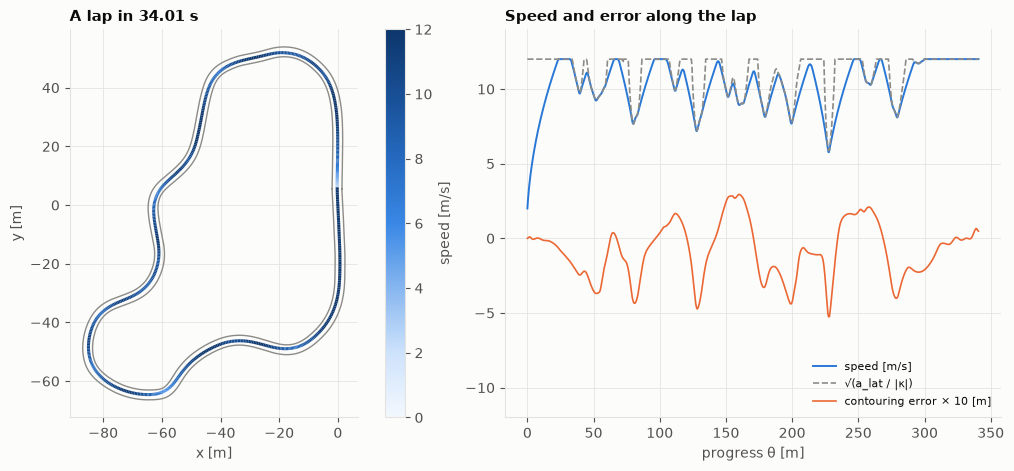

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.1, 1]})
normal = np.column_stack([-np.sin(heading), np.cos(heading)])
for side in (-1.0, 1.0):
  edge = position + side * half_width * normal
  ax1.plot(edge[:, 0], edge[:, 1], color=plotstyle.NEUTRAL, lw=1)
segments = np.stack([states[:-1, :2], states[1:, :2]], axis=1)
lines = LineCollection(segments, cmap=plotstyle.BLUES, norm=plt.Normalize(0.0, V_MAX), linewidths=2.2)
lines.set_array(states[:-1, 3])
ax1.add_collection(lines)
fig.colorbar(lines, ax=ax1, label="speed [m/s]")
ax1.set_aspect("equal")
ax1.set_title(f"A lap in {lap_time:.2f} s")
ax1.set_xlabel("x [m]")
ax1.set_ylabel("y [m]")
theta = states[:, 4]
ax2.plot(theta, states[:, 3], color=plotstyle.BLUE, lw=1.4, label="speed [m/s]")
ax2.plot(theta, np.sqrt(A_LAT / np.maximum(np.abs(np.interp(theta, sigma, curvature)), 1e-9)).clip(max=V_MAX), "--", color=plotstyle.NEUTRAL, lw=1.2, label="√(a_lat / |κ|)")
ax2.plot(theta, 10 * contour_err, color=plotstyle.ORANGE, lw=1.2, label="contouring error × 10 [m]")
ax2.set_xlabel("progress θ [m]")
ax2.set_ylim(-12, 14)
ax2.set_title("Speed and error along the lap")
ax2.legend(fontsize=8, loc="lower right")
plt.show()

The lap takes 34.0 s, 681 steps. Every solve converges, in 16 IPOPT iterations on average and a
median of 3.8 ms, which is 7.6 % of the 50 ms step. The car reaches the 12 m/s speed limit on
the straights, and brakes into the corners to the lateral-acceleration limit. The speed follows
the dashed curve $\sqrt{a_{lat} / |\kappa|}$ wherever that is below the limit, and runs above
it where the car cuts inside a corner, on a wider radius than the centre line's. The contouring
error stays within 0.53 m of the centre line, well inside the 1.18 m allowed.

The pair `pairs/contouring_mpc` (without the curvature term, on the chord-length spline)
reproduces CasADi's first solve to $10^{-13}$ and 200 closed-loop steps to $4 \times 10^{-13}$.
The 200 steps take 0.80 s against 9.6 s through CasADi's virtual machine and 1.6 s with its
oracles compiled (`examples/interp/README.md`).

## The generated C

`ctrl.law` is the controller as one Function, `law(x0, guess) -> (u, guess_next)`: IPOPT nested,
the track's tables and the warm start's shift in the same code.

In [8]:
module = write_module(ctrl.law, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB; guess_size = {ctrl.guess_size}")
print("\n".join(line for line in module.header.splitlines() if line.startswith(("int ", "static inline int"))))

mpcc_lap_law.c: 2718 lines, 942 kB; guess_size = 935
int mpcc_lap_law(const double** arg, double** res, int* iw, double* w, int mem);
int mpcc_lap_ipopt_stats(scaly_solver_stats* out);
static inline int mpcc_lap_law_call(const mpcc_lap_law_x0_t* x0, const mpcc_lap_law_guess_t* guess, mpcc_lap_law_u_t* u, mpcc_lap_law_guess_next_t* guess_next, mpcc_lap_law_workspace_t* workspace) {


The law is 2 718 lines and 942 kB of C, most of it the track's table of 5 440 numbers repeated in
each of the six generated functions that read it: the stage cost, the path constraint and their
first and second derivatives. The code generator does not yet share a constant table between the functions of a
module (todo C-187). The files are in `examples/generated/interp/contouring_control/` and link
against the vendored IPOPT.

## Checks

In [9]:
assert resample_error < 5e-3 and np.abs(np.sqrt(unit_speed) - 1).max() < 5e-3
assert abs(abs(turning) - 2 * np.pi) < 1e-9
assert first.status.ok and all(s in ("OK", "ACCEPTABLE") for s in statuses)
assert np.abs(contour_err).max() <= WIDTH + 1e-6 and np.abs(lateral).max() <= A_LAT + 1e-6
assert states[-1, 4] >= LAP and 20.0 < lap_time < 80.0
print("all 5 checks passed")

all 5 checks passed
